In [70]:
import os

import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.dataset import DiabeticRetinopathyDataset
from src.data.preprocessing import preprocess_pipeline

In [71]:
# Initiate custom PyTorch Dataset
df = pd.read_csv("../data/processed/aptos2019/splits/train_split.csv")
train_dataset = DiabeticRetinopathyDataset(
    img_dir="../data/raw/aptos2019/train_images",
    annotations_df=df
)

Augmentation steps:
- **Random Horizontal and Vertical Flips ($p=0.5$):** Retinal images do not have a strict physical orientation dependency.
    > *Note on Vertical Flipping:* Recent research ([*Machine learning technology in the classification of glaucoma severity using fundus photographs*, Thanapaisal et al., 2025](https://www.nature.com/articles/s41598-025-11697-1)) confirms vertical flipping is clinically valid, as pathologies appear in both hemispheres. This adds useful variability and makes the model robust to camera alignment.
- **Random Rotation ($\pm15^\circ$):** Simulates slight camera tilts.
- **Color Jitter (Brightness and Contrast $\pm10\%$):** Introduces minor illumination variations. This is kept intentionally subtle (10%) to prevent distorting the clinical features that were already carefully highlighted by the Ben Graham method.
- **Normalization:** Standardizing pixel values using ImageNet mean and standard deviation parameters.

Let's display the first 6 images from the training dataset in their original form, as well as in their preprocessed and augmented forms. Since the preprocessing pipeline ends with `transforms.Normalize(mean=[...], std=[...])` operation, visualizing the images requires performing inverse normalization and reordering the axes (PyTorch uses the `[C, H, W]` format, whereas Matplotlib uses `[H, W, C]`).


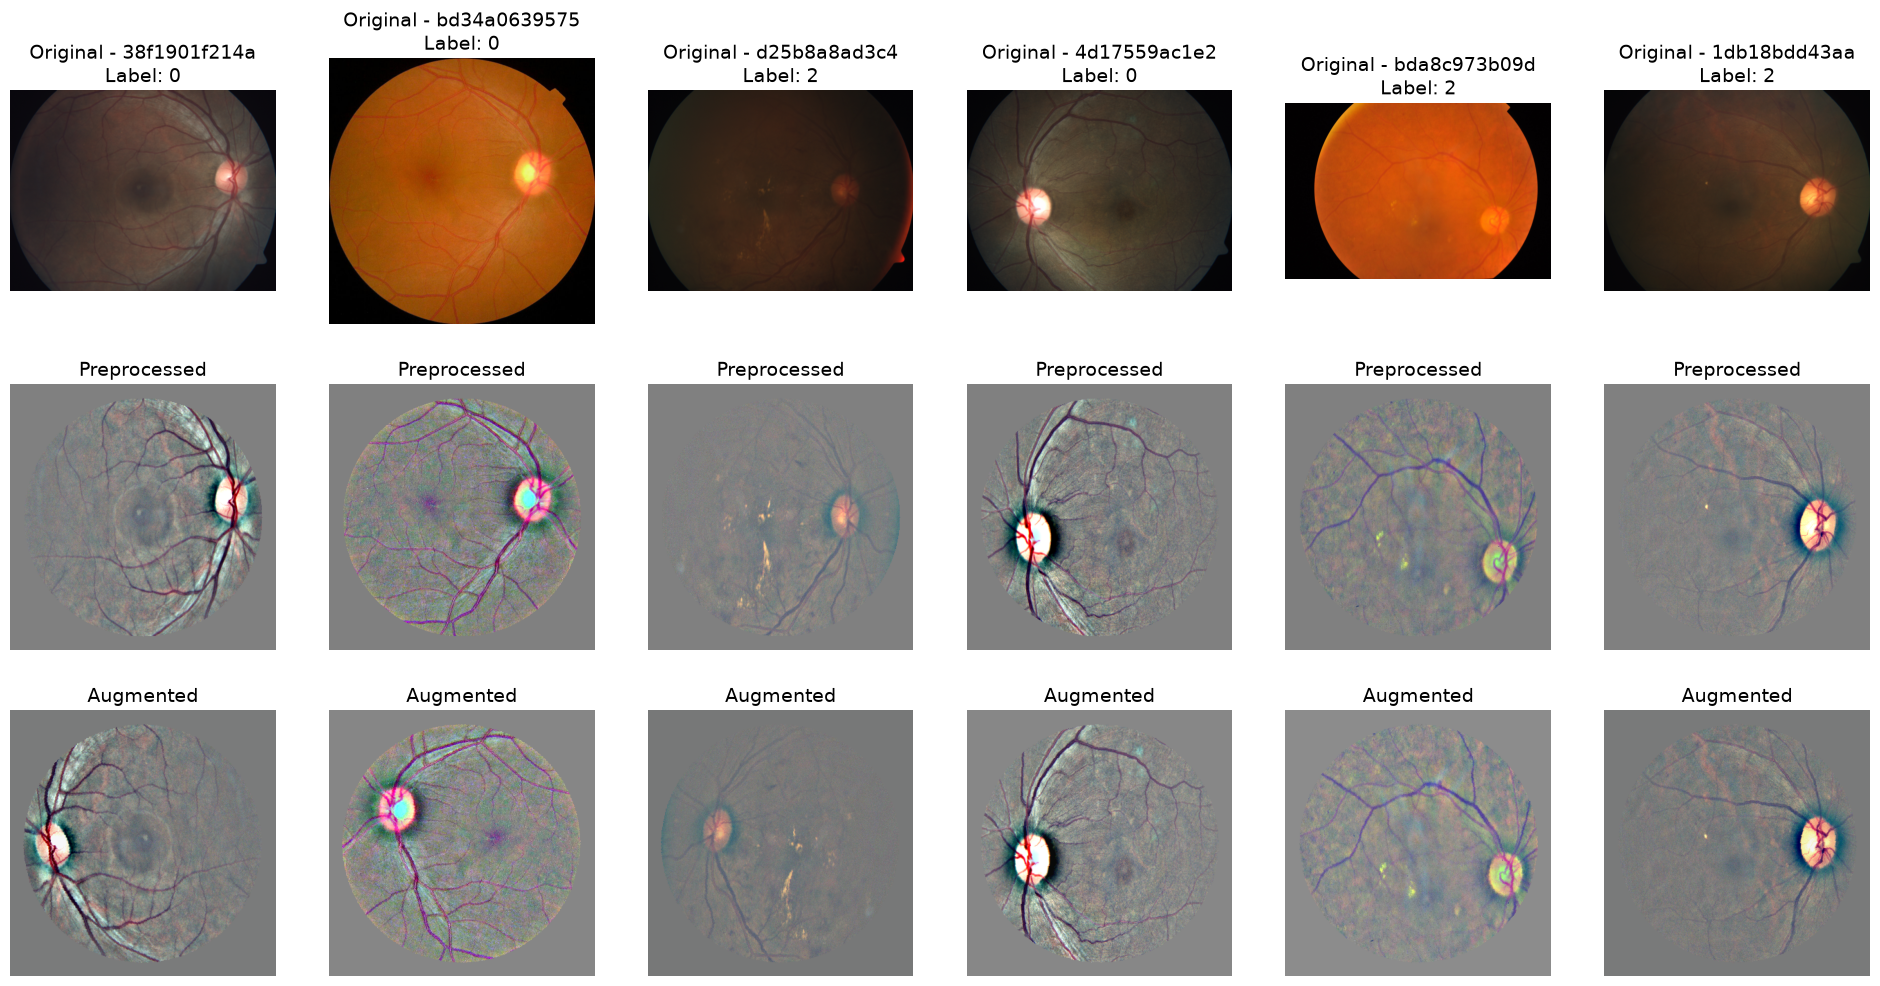

In [72]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, 6, figsize=(24, 12))

for i in range(6):
    img_id = train_dataset.image_ids[i]
    label = train_dataset.targets[i]
    img_path = os.path.join(train_dataset.img_dir, f"{img_id}.png")

    original_image = Image.open(img_path)
    prep_image = preprocess_pipeline(img_path)
    aug_image = train_dataset.transform(prep_image)
    aug_image = aug_image.numpy().transpose((1, 2, 0))
    aug_image = std * aug_image + mean
    aug_image = np.clip(aug_image, 0, 1)

    axes[0, i].imshow(original_image)
    axes[0, i].set_title(f"Original - {img_id}\nLabel: {label}", fontsize=14)
    axes[0, i].axis('off')
    axes[1, i].imshow(prep_image)
    axes[1, i].set_title("Preprocessed", fontsize=14)
    axes[1, i].axis('off')
    axes[2, i].imshow(aug_image)
    axes[2, i].set_title("Augmented", fontsize=14)
    axes[2, i].axis('off')

plt.show()

To better understand the variability of our augmentation pipeline, let's apply it multiple times to the same image.

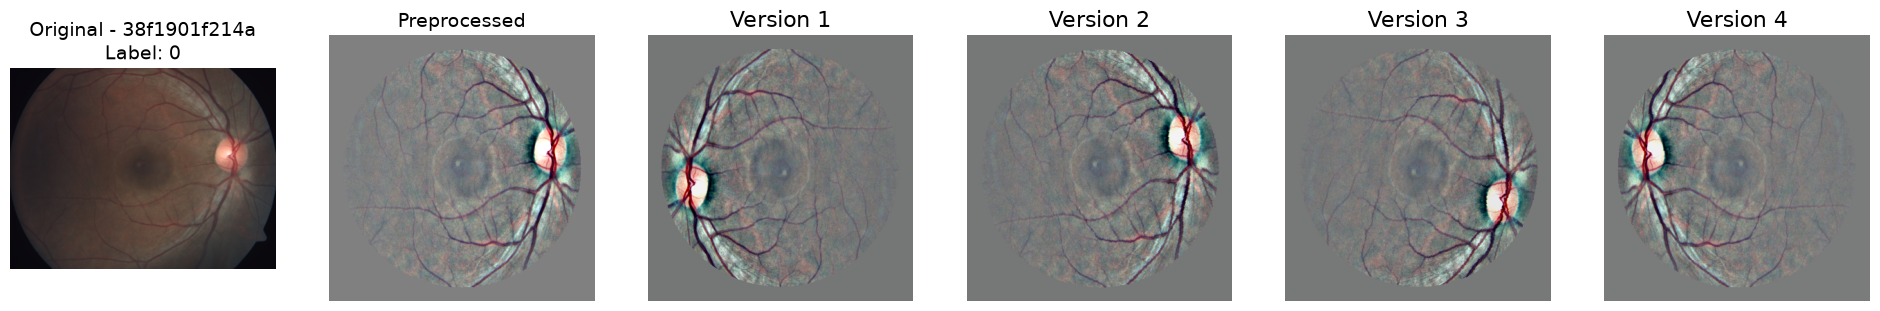

In [73]:
idx = 0
img_id = train_dataset.image_ids[idx]
label = train_dataset.targets[idx]
img_path = os.path.join(train_dataset.img_dir, f"{img_id}.png")

original_image = Image.open(img_path)
prep_image = preprocess_pipeline(img_path)

fig, axes = plt.subplots(1, 6, figsize=(24, 5))
axes[0].imshow(original_image)
axes[0].set_title(f"Original - {img_id}\nLabel: {label}", fontsize=14)
axes[0].axis('off')
axes[1].imshow(prep_image)
axes[1].set_title("Preprocessed", fontsize=14)
axes[1].axis('off')

for i in range(2, 6):
    aug_image = train_dataset.transform(prep_image)
    aug_image = aug_image.numpy().transpose((1, 2, 0))
    aug_image = std * aug_image + mean
    aug_image = np.clip(aug_image, 0, 1)
    axes[i].imshow(aug_image)
    axes[i].set_title(f"Version {i-1}", fontsize=16)
    axes[i].axis('off')

plt.show()